In [6]:
import requests

url = "https://gist.githubusercontent.com/romaklimenko/c95f3a864828f7f034b7a33d1676e420/raw/55f9027799b5b3c67e2f7cb3d6a7154f707ff08a/warandpeace.txt"
text = requests.get(url).text

print(text[:500])

Лев Николаевич Толстой
Война и мир

Первый вариант романа

От автора

  
   Я пишу до сих пор только о князьях, графах, министрах, сенаторах и их детях и боюсь, что и вперед не будет других лиц в моей истории.
   Может быть, это нехорошо и не нравится публике; может быть, для нее интереснее и поучительнее история мужиков, купцов, семинаристов, но, со всем моим желанием иметь как можно больше читателей, я не могу угодить такому вкусу, по многим причинам.
   Во-первых, потому, что памятники истори


In [7]:
len(text)

1901009

In [9]:
# import requests
#
# url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
# text = requests.get(url).text
#
# print(text[:500])

In [10]:
# len(text)

In [11]:
import torch

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}


def encode(s):
    return [stoi[c] for c in s]


def decode(l):
    return ''.join([itos[i] for i in l])


data = torch.tensor(encode(text), dtype=torch.long)

In [12]:
seq_len = 50


def get_batch():
    i = torch.randint(len(data) - seq_len - 1, (1,))
    x = data[i:i + seq_len]
    y = data[i + 1:i + seq_len + 1]
    return x.unsqueeze(0), y.unsqueeze(0)

In [13]:
"".join([decode(code) for code in (get_batch()[0]).tolist()])

'ю пучину этой лжи, всю отдаленность понятия о войн'

In [14]:
import torch.nn as nn


class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        x = self.embed(x)
        out, h = self.rnn(x, h)
        out = self.fc(out)
        return out, h

In [15]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        x = self.embed(x)
        out, h = self.lstm(x, h)
        out = self.fc(out)
        return out, h

In [16]:
def train(model, epochs=2000):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
    criterion = nn.CrossEntropyLoss()

    losses = []

    for epoch in range(epochs):
        x, y = get_batch()

        logits, _ = model(x)

        loss = criterion(
            logits.view(-1, vocab_size),
            y.view(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 200 == 0:
            print(f"step {epoch:4}, loss {loss.item():.4f}")

        losses.append(loss.item())

    return losses

In [17]:
def generate(model, start="To be", length=200, temperature=1):
    model.eval()

    x = torch.tensor([encode(start)], dtype=torch.long)
    h = None

    result = list(start)

    for _ in range(length):
        logits, h = model(x, h)

        # no temp
        # probs = torch.softmax(logits, dim=-1)

        # temp
        logits = logits[:, -1, :] / temperature
        probs = torch.softmax(logits, dim=-1)

        idx = torch.multinomial(probs, num_samples=1).item()

        result.append(itos[idx])

        x = torch.tensor([[idx]])

    return ''.join(result)

In [18]:
# RNN
rnn_model = CharRNN(vocab_size, 128)

In [19]:
from torchinfo import summary
summary(rnn_model)

Layer (type:depth-idx)                   Param #
CharRNN                                  --
├─Embedding: 1-1                         17,408
├─RNN: 1-2                               33,024
├─Linear: 1-3                            17,544
Total params: 67,976
Trainable params: 67,976
Non-trainable params: 0

In [20]:
rnn_losses  = train(rnn_model, epochs=20_000)

step    0, loss 4.9024
step  200, loss 2.7070
step  400, loss 2.1965
step  600, loss 2.1351
step  800, loss 2.1992
step 1000, loss 2.1234
step 1200, loss 2.6384
step 1400, loss 1.8043
step 1600, loss 2.1682
step 1800, loss 2.3544
step 2000, loss 2.1850
step 2200, loss 2.1127
step 2400, loss 2.0049
step 2600, loss 2.0684
step 2800, loss 2.1732
step 3000, loss 2.5589
step 3200, loss 1.8840
step 3400, loss 1.8166
step 3600, loss 1.6836
step 3800, loss 2.3442
step 4000, loss 1.8716
step 4200, loss 2.5783
step 4400, loss 2.0055
step 4600, loss 2.2124
step 4800, loss 1.6144
step 5000, loss 1.6288
step 5200, loss 1.9244
step 5400, loss 1.9397
step 5600, loss 1.6301
step 5800, loss 1.9339
step 6000, loss 1.6951
step 6200, loss 2.0930
step 6400, loss 2.3281
step 6600, loss 1.6213
step 6800, loss 2.5768
step 7000, loss 2.3149
step 7200, loss 2.1514
step 7400, loss 2.1097
step 7600, loss 2.0141
step 7800, loss 1.7858
step 8000, loss 1.6217
step 8200, loss 2.0297
step 8400, loss 2.0627
step 8600, 

In [30]:
print(generate(rnn_model, start="Привет"))

Приветить, особенностую и Друсть бражива, тот, поворила, верося, присобхавая задрому бувставая ехате.
   Клицами. На мило или добел силый разнемчесть сындрие. Ико был кто нимами, первыми, напосу сказали, на


In [22]:
# LSTM
lstm_model = CharLSTM(vocab_size, 128)

In [23]:
lstm_losses = train(lstm_model, epochs=20_000)

step    0, loss 4.9246
step  200, loss 2.5012
step  400, loss 2.3945
step  600, loss 2.4675
step  800, loss 2.3053
step 1000, loss 2.5021
step 1200, loss 1.9990
step 1400, loss 2.5353
step 1600, loss 2.2537
step 1800, loss 2.2063
step 2000, loss 1.9440
step 2200, loss 2.1404
step 2400, loss 2.1859
step 2600, loss 2.3269
step 2800, loss 1.8307
step 3000, loss 1.6194
step 3200, loss 1.7591
step 3400, loss 1.7709
step 3600, loss 1.7643
step 3800, loss 1.8437
step 4000, loss 1.8077
step 4200, loss 2.0620
step 4400, loss 1.9206
step 4600, loss 1.7674
step 4800, loss 1.7289
step 5000, loss 2.2792
step 5200, loss 1.7700
step 5400, loss 1.8142
step 5600, loss 1.8751
step 5800, loss 1.5680
step 6000, loss 2.0244
step 6200, loss 2.0876
step 6400, loss 1.7827
step 6600, loss 1.6604
step 6800, loss 1.9396
step 7000, loss 1.8878
step 7200, loss 2.0458
step 7400, loss 1.5488
step 7600, loss 1.6357
step 7800, loss 2.1720
step 8000, loss 2.0404
step 8200, loss 1.9795
step 8400, loss 1.9118
step 8600, 

In [24]:
from torchinfo import summary
summary(lstm_model)

Layer (type:depth-idx)                   Param #
CharLSTM                                 --
├─Embedding: 1-1                         17,408
├─LSTM: 1-2                              132,096
├─Linear: 1-3                            17,544
Total params: 167,048
Trainable params: 167,048
Non-trainable params: 0

In [48]:
print(generate(lstm_model, start="Привет"))

Привете, бог могло до но шеетой Андреминской.
   -- Дал проводном вназала он рыбеннулся половитей, по земели, простить, и, что ему его но просовал. -- Дутен по вместе. Притивостнекие и подал. Анна Милось, г


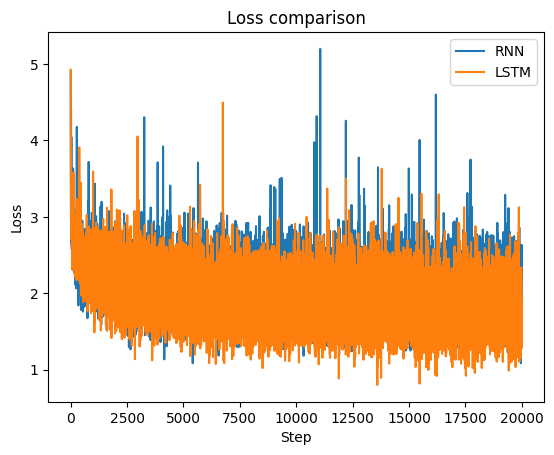

In [26]:
import matplotlib.pyplot as plt

plt.plot(rnn_losses, label="RNN")
plt.plot(lstm_losses, label="LSTM")
plt.legend()
plt.title("Loss comparison")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()